# Tripartite Population Dynamics

# Generalized Lotka–Volterra framework
We model a closed, well-mixed batch culture, where three microbial strategies co-exist: a public metabolizer $(P)$, cheater $(C)$, and a private metabolizer $(M)$.
Sucrose is continuously supplied as the sole carbon source. 
The public metabolizer secretes  extracellular invertase, hydrolyzing sucrose into glucose in the surrounding medium. 
This glucose is partially assimilated for its own growth, while the rest becomes part of a common resource pool accessible to other community members. 
Cheaters exploit this resource pool without contributing the enzyme themselves, and their growth is thus dependent on the availability of shared glucose.
In contrast, private metabolizers internalize sucrose and cleave it intracellularly, thereby bypassing the common pool and avoiding cross-feeding interactions altogether. 

To describe the ecological dynamics of these three strategies, we employ a generalized Lotka–Volterra framework that captures intrinsic growth, pairwise interactions, and density-dependent effects. 
Importantly, we assume that public metabolizers constitutively express invertase at a constant rate throughout their lifetime. 
Consequently, we do not explicitly model the dynamics of enzyme regulation, as is common in other approaches. 
This assumption allows us to avoid explicitly modelling enzyme regulation, thereby reducing model complexity. At the same time, it preserves ecological realism, since cheater growth remains directly dependent on the activity and density of public metabolizers.

The resulting system is governed by a set of coupled ordinary differential equations:
\begin{equation}\label{eq:LV} 
\begin{cases}
\frac{dP}{dt} & = r_p \cdot P - \alpha \cdot P\cdot C - \beta \cdot P \cdot M - \eta \cdot P ^2 \\
\frac{dC}{dt}  & = \alpha \cdot P\cdot C - \nu \cdot C^2 \\
\frac{dM}{dt} & = r_m \cdot M - \beta \cdot M \cdot P - \gamma \cdot M^2
\end{cases}
\end{equation} 
with seven parameters: intrinsic growth rates ($r_p$, $ r_m $), cooperation parameters ($ \alpha $) and competition ($ \beta $), and density ($ \eta$,$ \gamma$, $ \nu$ ).
The cheater population does not contribute to enzyme production and relies entirely on the glucose released by public metabolizers. Its growth rate is therefore jointly determined by the cooperation coefficient $ \alpha $ and the density of public metabolizers.
However, to prevent uncontrolled proliferation, cheater growth is also regulated by density-dependent constraints $\nu$. 
This model is designed to be readily parameterizable from empirical data.
To ensure broad applicability and experimental integration, we present a stepwise protocol for parameter estimation based on monoculture and pairwise co-culture experiments. This framework enables researchers to directly map ecological interactions onto measurable population dynamics, bridging theoretical modeling with empirical observation.


# Coexistance of three population(Evalutionary game theory)
- Proportion of Public population :  

$$
P^* \;=\;\frac{r_p\,\gamma \;-\;\beta\,r_m}{\alpha^2\,\gamma \;+\;\nu\,\eta\,\gamma \;-\;\nu\,\beta^2}
$$
- Proportion of Cheaters :  
$$
C^* \;=\;\frac{\alpha\,\bigl(r_p\,\gamma \;-\;\beta\,r_m\bigr)}{\alpha^2\,\gamma \;+\;\nu\,\eta\,\gamma \;-\;\nu\,\beta^2}
$$

- Proportion of Privates :  

$$
M^* \;=\;\frac{\alpha^2\,r_m \;+\;\eta\,\nu\,r_m \;-\;\beta\,\nu\,r_p}{\alpha^2\,\gamma \;+\;\nu\,\eta\,\gamma \;-\;\nu\,\beta^2}
$$


These expressions describe the equilibrium point where all three strategies coexist in the population. The coexistence of $ P$, $ C $, and $ M $ in the mixed ESS represents a delicate balance governed by intrinsic growth rates, competition, and exploitation dynamics.

### Imports

In [3]:
from src.model import deriv
from src.parameters import parameters
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import odeint
import os

## test analysis

In [4]:
from src.parameters import parameters
print(parameters)


{'beta': 0.0001, 'gamma': 0.0001, 'alpha': 0.0003, 'eta': 0.0001, 'r_c': 2.0, 'r_p': 1.0, 'nu': 0.0001}


# Game Theory( 3 species and 3 streatgy)

## simplex replicator_dynamics[ Growth rate shifting (payoff advantage)]

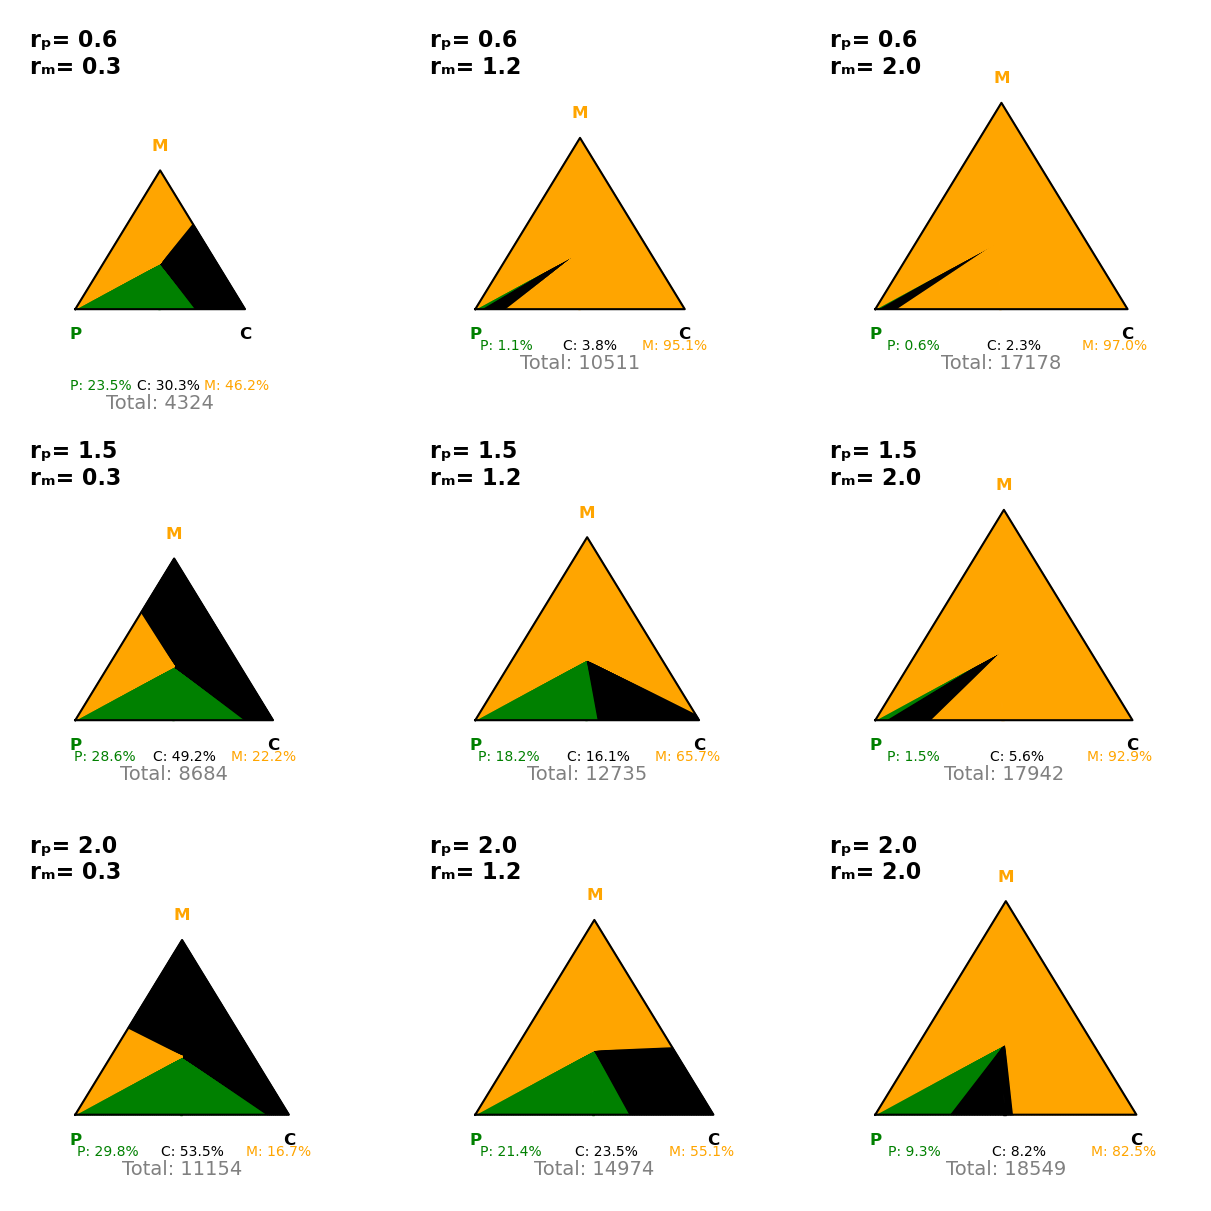

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import os, math

# ------------ parameters ------------
base = dict(r_p=0.02, r_m=0.02,
            alpha=0.0002, beta=0.0001,
            eta=0.0001, gamma=0.0001, nu=0.00001)

rp_vals=[0.6,1.5,2.0]
rm_vals=[0.3,1.2,2.0]

def simplex_grid(n=10):
    return np.array([[a/n,b/n,(n-a-b)/n]
                     for a in range(n+1) for b in range(n+1-a)])

grid=simplex_grid()

t=np.linspace(0,300,800)
def dyn(x,t,p):
    P,C,M=x
    return [p['r_p']*P-p['alpha']*P*C-p['beta']*P*M-p['eta']*P**2,
            p['alpha']*P*C-p['nu']*C**2,
            p['r_m']*M-p['beta']*M*P-p['gamma']*M**2]

# simulate
res={}
for i,rp in enumerate(rp_vals):
    for j,rm in enumerate(rm_vals):
        p=base.copy(); p['r_p']=rp; p['r_m']=rm
        finals=np.array([odeint(dyn,x0,t,args=(p,))[-1] for x0 in grid])
        avg=finals.mean(axis=0)
        res[(i,j)]={'prop':avg/avg.sum(),'total':avg.sum(),'r_p':rp,'r_m':rm}

totals=np.array([v['total'] for v in res.values()])
lo,hi=totals.min(),totals.max()
scale=lambda tot:0.65+0.35*(tot-lo)/(hi-lo) if hi!=lo else 1.0

# plotting
fig,axes=plt.subplots(3,3,figsize=(12,12),constrained_layout=True)
#fig, axes = plt.subplots(3, 3, figsize=(15, 12))  # REMOVE constrained_layout
#fig.subplots_adjust(wspace=0.00, hspace=0.01, left=0.05, right=0.98, top=0.96, bottom=0.06)
   

A0,B0,C0=np.array([0,0]),np.array([1,0]),np.array([.5,math.sqrt(3)/2])
VERTEX_DY=0.07; LINE_Y=-0.12; TOTAL_Y=-0.18
shift={(0,0):-0.16}

for (i,j),d in res.items():
    ax=axes[i,j]
    s=scale(d['total'])
    A,B,C=A0*s,B0*s,C0*s
    prop=d['prop']

    # colour fill
    cum=np.cumsum(np.concatenate([[0],prop]))
    def pt(f):
        if f<=1/3: return A+(B-A)*f*3
        elif f<=2/3: return B+(C-B)*(f-1/3)*3
        else: return C+(A-C)*(f-2/3)*3
    for k in range(300):
        f1,f2=k/300,(k+1)/300
        col='#008000' if cum[1]>f1>=cum[0] else '#000000' if cum[2]>f1>=cum[1] else '#FFA500'
        ax.fill(*zip(pt(f1),pt(f2),(A+B+C)/3),color=col,edgecolor=col)
    ax.plot([A[0],B[0],C[0],A[0]],[A[1],B[1],C[1],A[1]],'k-',lw=1.5)

    # vertex labels
    ax.text(A[0],A[1]-VERTEX_DY,'P',ha='center',va='top',fontsize=12,fontweight='bold',color='#008000')
    ax.text(B[0],B[1]-VERTEX_DY,'C',ha='center',va='top',fontsize=12,fontweight='bold',color='#000000')
    ax.text(C[0],C[1]+VERTEX_DY,'M',ha='center',va='bottom',fontsize=12,fontweight='bold',color='#FFA500')

    # ratio + total
    dy=shift.get((i,j),0)
    y_ratio=LINE_Y+dy; y_total=TOTAL_Y+dy
    
    for f,text,color in zip((0.15,0.55,0.95),
                           [f"P: {prop[0]*100:.1f}%",
                             f"C: {prop[1]*100:.1f}%",
                            f"M: {prop[2]*100:.1f}%"],
                            ['#008000','#000000','#FFA500']):
        ax.text(A[0]+f*(B[0]-A[0]),y_ratio,text,ha='center',va='top',fontsize=10,color=color)
    ax.text((A[0]+B[0])/2,y_total,f"Total: {int(d['total'])}",ha='center',va='top',fontsize=14,color='gray')

    # rp,rm upper‑left but closer (x=0.05, y=0.95 in Axes coords)
    ax.text(0.05,0.95,f"rₚ= {d['r_p']}\nrₘ= {d['r_m']}",
            transform=ax.transAxes,ha='left',va='top',fontsize=16,fontweight='bold',linespacing=1.2)

    ax.set_xlim(-0.25,1.25); ax.set_ylim(-0.35,C0[1]+0.35); ax.axis('off')

os.makedirs("output/figures",exist_ok=True)
out="output/figures/triangle_population_proportion.png"
plt.savefig(out,dpi=600);
plt.show()



## Stream plot

If arrows point toward a corner ( toward "Private M"), it means the system evolves toward dominance of that population.If arrows spiral or circulate, it means the system has oscillations or cycling between populations.If arrows converge to a point inside, it shows a stable coexistence (a steady balance of Public, Cheaters, and Private).

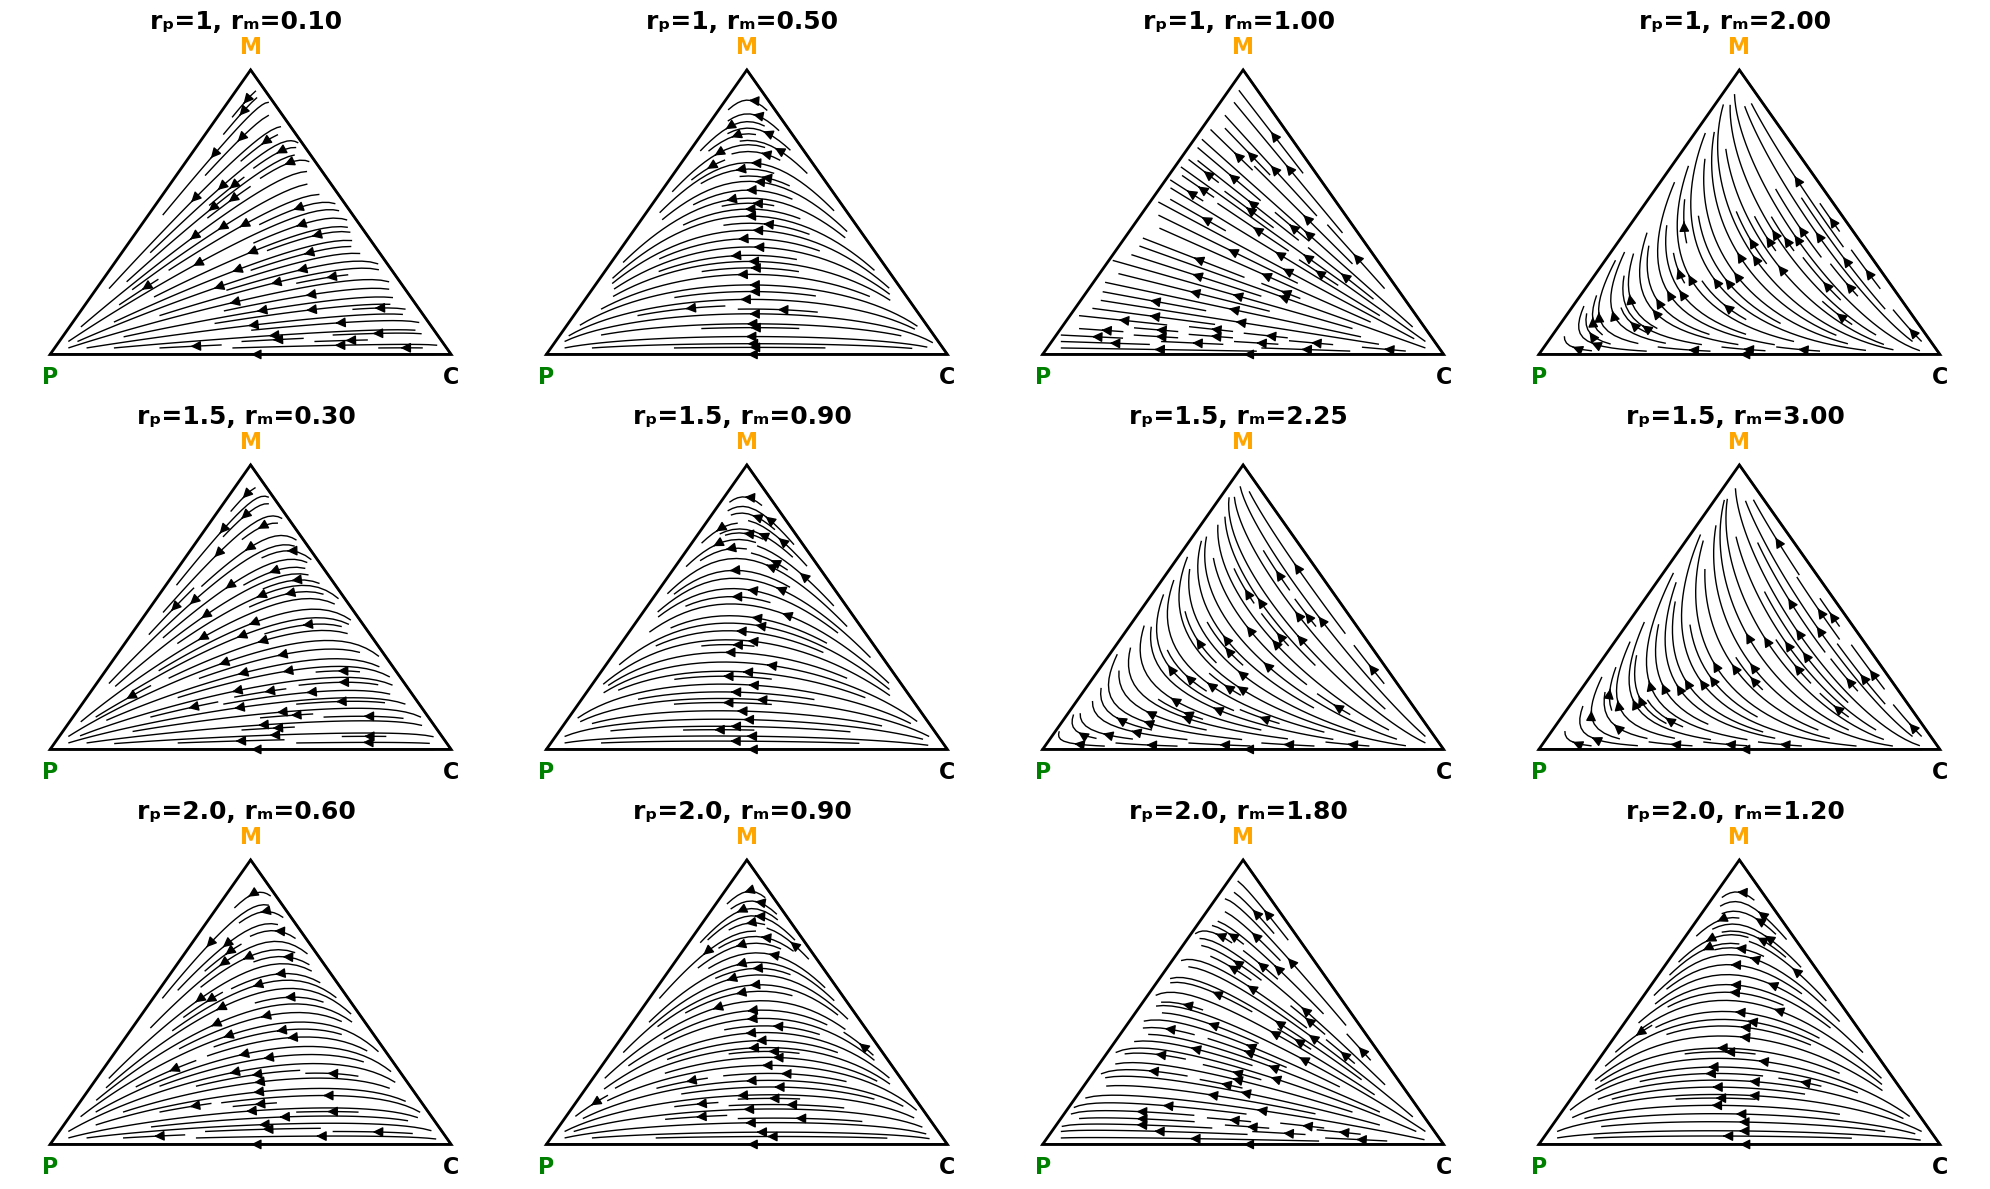

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import os

# Parameters
parameters = {
    "beta": 0.0001,
    "gamma": 0.0001,
    "alpha": 0.0002,
    "eta": 0.0001,  
    "nu": 0.0001
}

# ODE system
def population_dynamics(x, t, params):
    P, C, M = x
    dPdt = params["r_p"] * P - params["alpha"] * P * C - params["beta"] * P * M - params["eta"] * P**2
    dCdt = params["alpha"] * P * C - params["nu"] * C**2
    dMdt = params["r_m"] * M - params["beta"] * M * P - params["gamma"] * M**2
    return np.array([dPdt, dCdt, dMdt])

# Barycentric to Cartesian for visualization
def to_cartesian(x):
    return np.array([
        0.5 * (2 * x[:, 1] + x[:, 2]),
        np.sqrt(3) / 2 * x[:, 2]
    ]).T

# Cartesian to Barycentric for visualization
def cartesian_to_barycentric(xy):
    x, y = xy[..., 0], xy[..., 1]
    l1 = 1 - x - y / np.sqrt(3)
    l2 = x - y / np.sqrt(3)
    l3 = 2 * y / np.sqrt(3)
    return np.stack([l1, l2, l3], axis=-1)

# rp and corresponding rm ratios
rp_values = [1, 1.5, 2.0]  # You can extend if needed
rm_ratios_list = [
    [0.10, 0.5, 1.0, 2.0],   # for 1st rp (1)
    [0.20, 0.60, 1.50, 2.00],# for 2nd rp (1.5)
    [0.30, 0.45, 0.90, 0.60] # for 3rd rp (2.0)
]

# Set up figure
fig, axes = plt.subplots(len(rp_values), 4, figsize=(20, 12))  # 4 rm per rp

for i, rp in enumerate(rp_values):
    rm_ratios = rm_ratios_list[i]

    for j, rm_ratio in enumerate(rm_ratios):
        rm = rm_ratio * rp

        parameters["r_p"] = rp
        parameters["r_m"] = rm

        ax = axes[i, j]
        triangle_vertices = np.array([[0, 0], [1, 0], [0.5, np.sqrt(3)/2]])

        grid_size = 30
        x = np.linspace(0, 1, grid_size)
        y = np.linspace(0, np.sqrt(3)/2, grid_size)
        X, Y = np.meshgrid(x, y)
        XY = np.stack([X, Y], axis=-1)
        bary = cartesian_to_barycentric(XY)

        mask = (bary >= 0).all(axis=-1)
        U = np.zeros_like(X)
        V = np.zeros_like(Y)

        for m in range(grid_size):
            for n in range(grid_size):
                if not mask[m, n]:
                    U[m, n] = V[m, n] = np.nan
                    continue

                x0 = bary[m, n]
                x0_scaled = x0 * 10

                sol = odeint(population_dynamics, x0_scaled, [0, 0.1], args=(parameters,))
                direction = sol[-1] - sol[0]

                if np.allclose(direction, 0):
                    U[m, n] = V[m, n] = 0
                    continue

                x1 = sol[-1]
                if np.any(x1 < 0):
                    U[m, n] = V[m, n] = 0
                    continue

                start_cart = to_cartesian(np.array([x0]))[0]
                end_cart = to_cartesian(np.array([x1/np.sum(x1)]))[0]
                vec = end_cart - start_cart

                U[m, n] = vec[0]
                V[m, n] = vec[1]

        # Plotting
        ax.streamplot(X, Y, U, V, color='black', linewidth=1, density=1.5, arrowsize=1.5)
        ax.plot(triangle_vertices[:, 0], triangle_vertices[:, 1], 'k-', linewidth=1.5)
        ax.fill(triangle_vertices[:, 0], triangle_vertices[:, 1], edgecolor='black', linewidth=2, fill=False)
        ax.text(0, -0.09, 'P', fontsize=16, fontweight='bold', ha='center', color='#008000')
        ax.text(1, -0.09, 'C', fontsize=16, fontweight='bold', ha='center', color='#000000')
        ax.text(0.5, np.sqrt(3)/2 + 0.05, 'M', fontsize=16, fontweight='bold', ha='center', color='#FFA500')

        ax.set_title(f"rₚ={rp}, rₘ={rm:.2f} ", fontsize=18, fontweight="bold")
        ax.set_xlim(-0.1, 1.1)
        ax.set_ylim(-0.1, np.sqrt(3)/2 + 0.1)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_frame_on(False)

# Save and show
plt.tight_layout()
os.makedirs("output/figures", exist_ok=True)
plt.savefig("output/figures/simplex_population_streamlines.png", dpi=300)
plt.show()


## ESS Analysis

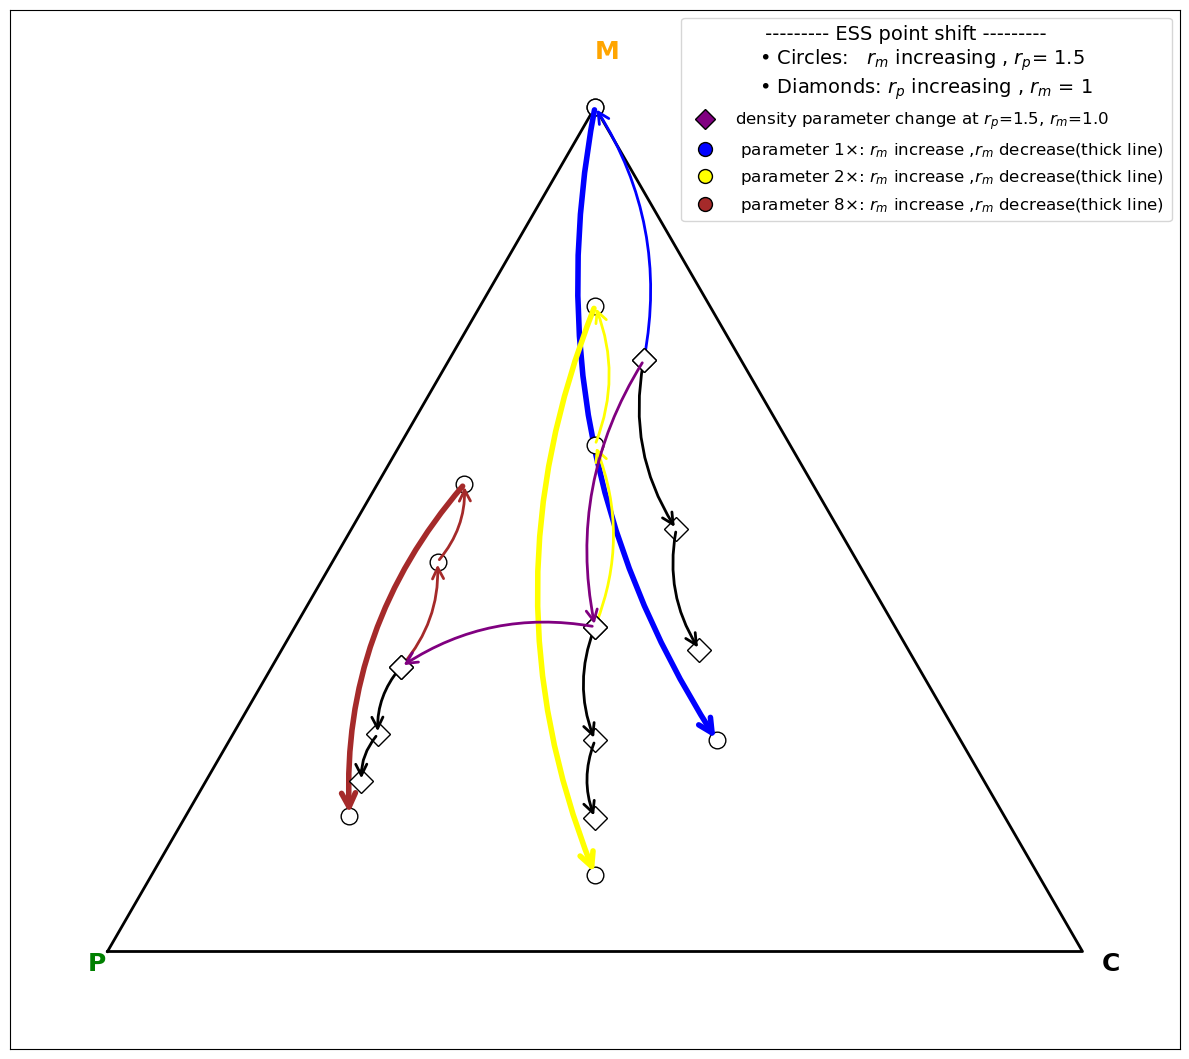

In [2]:
import numpy as np
import matplotlib.pyplot as plt


def calculate_equilibrium(alpha, beta, gamma, nu, eta, rp, rm):
    """Compute equilibrium proportions of P, C, M."""
    denom = alpha**2 / nu + eta - beta**2 / gamma
    P = max(0, (rp - beta * rm / gamma) / denom)
    C = max(0, (alpha * P) / nu)
    M = max(0, (rm - beta * P) / gamma)
    tot = P + C + M
    return np.array([P, C, M]) / tot if tot > 0 else np.array([np.nan, np.nan, np.nan])

def to_triangular(m, c):
    """Map proportions to triangular coordinates."""
    x = c + 0.5 * m
    y = (np.sqrt(3) / 2) * m
    return x, y

def plot_path(ax, points, style, color='black', label=None, highlight_index=None):
    """Plot points with arrows connecting them. One arrow can be highlighted (e.g., thicker)."""
    for x, y in points:
        ax.plot(x, y, style, color=color, mec='black', mfc='white', ms=12, zorder=3)
    for i in range(1, len(points)):
        arrow_kwargs = dict(arrowstyle='->', color=color, lw=2,
                            mutation_scale=20, connectionstyle='arc3,rad=0.2')
        if highlight_index is not None and i == highlight_index:
            arrow_kwargs['lw'] = 4  # Thicker line
            arrow_kwargs['mutation_scale'] = 25
        ax.annotate('', xy=points[i], xytext=points[i - 1],
                    arrowprops=arrow_kwargs,
                    zorder=3)

# ---------- Setup Parameters and Figure ----------

# Constants
alpha = 0.0002
beta = 0.0001
base_eta = base_gamma = base_nu = 0.0001
scales = [1, 2, 8]
colors = ['blue', 'yellow', 'brown']
rp_vals = [1.5, 2.0, 2.5]
rm_vals = [1.0, 1.5, 2, 0.5]

# Initialize plot
fig, ax = plt.subplots(figsize=(12, 12))
triangle = np.array([[0, 0], [1, 0], [0.5, np.sqrt(3)/2]])
ax.fill(triangle[:, 0], triangle[:, 1], color='white', alpha=0.25)
ax.plot(*triangle.T, 'k-', lw=2)
ax.plot(*triangle[[2, 0]].T, 'k-', lw=2)  # Close triangle

# ---------- Main Plotting Logic ----------

for i, scale in enumerate(scales):
    eta = base_eta * scale
    gamma = base_gamma * scale
    nu = base_nu * scale
    color = colors[i]

    # Fixed rp = 2.5, vary rm
    points_rm = [to_triangular(*calculate_equilibrium(alpha, beta, gamma, nu, eta, 1.5, rm)[[2,1]])
                 for rm in rm_vals]
    
    # Highlight the arrow going into rm = 0.5
    rm_index = rm_vals.index(0.5)
    plot_path(ax, points_rm, 'o', color=color, highlight_index=rm_index)

    # Fixed rm = 1.0, vary rp
    points_rp = [to_triangular(*calculate_equilibrium(alpha, beta, gamma, nu, eta, rp, 1.0)[[2,1]])
                 for rp in rp_vals]
    plot_path(ax, points_rp, 'D', color='black')

# Fixed (rp, rm), vary scale
points_scale = [to_triangular(*calculate_equilibrium(alpha, beta, base_gamma*scale, base_nu*scale, base_eta*scale, 1.5, 1.0)[[2,1]])
                for scale in scales]
plot_path(ax, points_scale, 'D', color='purple')

# ---------- Triangle Labels and Legend ----------

ax.text(-0.02, -0.02, 'P', fontsize=18, fontweight='bold', color='green')
ax.text(1.02, -0.02, 'C', fontsize=18, fontweight='bold', color='black')
ax.text(0.5, np.sqrt(3)/2 + 0.05, 'M', fontsize=18, fontweight='bold', color='orange')

circle_legend = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[i],
                            markeredgecolor='black', markersize=10) for i in range(len(scales))]
diamond_legend = [plt.Line2D([0], [0], marker='D', color='w', markerfacecolor='purple',
                             markeredgecolor='black', markersize=10)]

ax.legend( diamond_legend+circle_legend,['density parameter change at $r_p$=1.5, $r_m$=1.0']+
          [f' parameter {s}×: $r_m$ increase ,$r_m$ decrease(thick line) ' for s in scales] ,
          
          title=' --------- ESS point shift ---------  \n• Circles:   $ r_m$ increasing , $r_p$= 1.5 \n• Diamonds: $r_p$ increasing , $r_m $ = 1 ', 
          loc='upper right', fontsize=12, title_fontsize=14)

# ---------- Finalize Layout ----------

ax.set_xticks([])
ax.set_yticks([])
ax.set_xlim(-0.1, 1.1)
ax.set_ylim(-0.1, np.sqrt(3)/2 + 0.1)
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig("output/figures/triangle_ESS_shift_final.png", dpi=300)
plt.show()
